In [ ]:
#Assignment No 5:-Assignment based on Advanced Clustering for Pattern Discovery and Anomaly Detection Exemplar
#Name-Deokar Shraddha Sunil
#Roll No-153 B

In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
#Load the dataset
df = pd.read_csv("UNSW_NB15_training-set.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
# Explore Dataset(Basic operations)
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

label
1    45332
0    37000
Name: count, dtype: int64

In [6]:
# Handle Missing Values
df.isnull().sum()
df = df.dropna()

In [7]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [8]:
#Feature Engineering
X = df.drop(['id','label'], axis=1)
y = df['label']


In [9]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Take a smaller sample of dataset
df_sample = df.sample(n=10000, random_state=42)

# Separate features and label
X = df_sample.drop(['id','label','attack_cat'], axis=1)
y = df_sample['label']

# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=8)

clusters = dbscan.fit_predict(X_scaled)

print(clusters[:10])

[0 1 1 2 3 1 4 9 3 1]


In [13]:
# Add cluster results to sampled dataset
df_sample['cluster'] = clusters

df_sample.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,cluster
38666,38667,1.292678,111,3,3,52,54,2934,3740,81.226725,...,4,1,1,0,7,1,0,6,0,0
56460,56461,0.000007,117,2,4,2,0,114,0,142857.140900,...,4,0,0,0,5,4,0,5,1,1
16266,16267,0.000010,117,2,4,2,0,114,0,100000.002500,...,51,0,0,0,23,51,0,5,1,1
75603,75604,0.000000,6,0,4,1,0,46,0,0.000000,...,1,0,0,0,1,1,1,6,0,2
11200,11201,0.189998,111,0,3,10,6,1460,268,78.948199,...,1,0,0,0,1,1,0,3,1,3


In [ ]:
#Anaomaly Detection
anomalies = df_sample[df_sample['cluster'] == -1]

print("Total anomalies detected:", len(anomalies))

anomalies.head()

Total anomalies detected: 1000


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,cluster
11270,11271,2.223076,111,7,3,54,248,2424,304406,135.397974,...,1,0,0,0,1,1,0,3,1,-1
28569,28570,30.983368,6,0,2,4,4,184,112,0.225928,...,2,0,0,0,2,2,0,6,0,-1
46344,46345,0.735916,111,0,3,36,18,28032,1342,72.019087,...,1,0,0,0,1,1,0,3,1,-1
57763,57764,1.272488,111,0,3,116,34,132544,2288,117.093442,...,1,0,0,0,1,1,0,3,1,-1
6009,6010,1.903207,111,0,3,38,160,1880,193931,103.509500,...,1,0,0,0,1,1,0,3,1,-1


In [17]:
predicted = np.where(df_sample['cluster'] == -1, 1, 0)

In [18]:
#Confusion Matrix 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, predicted)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3964  486]
 [5036  514]]


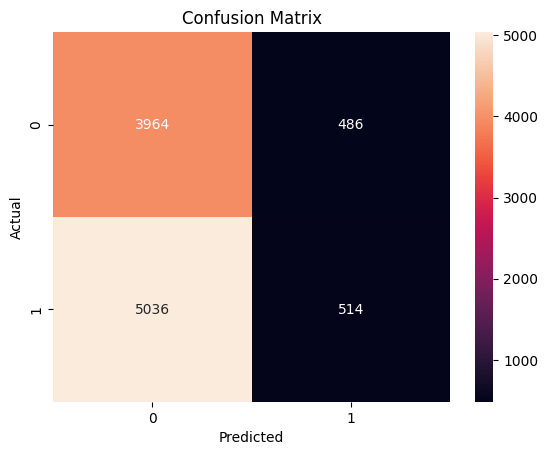

In [ ]:
#Heatmap of confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y, predicted))

              precision    recall  f1-score   support

           0       0.44      0.89      0.59      4450
           1       0.51      0.09      0.16      5550

    accuracy                           0.45     10000
   macro avg       0.48      0.49      0.37     10000
weighted avg       0.48      0.45      0.35     10000



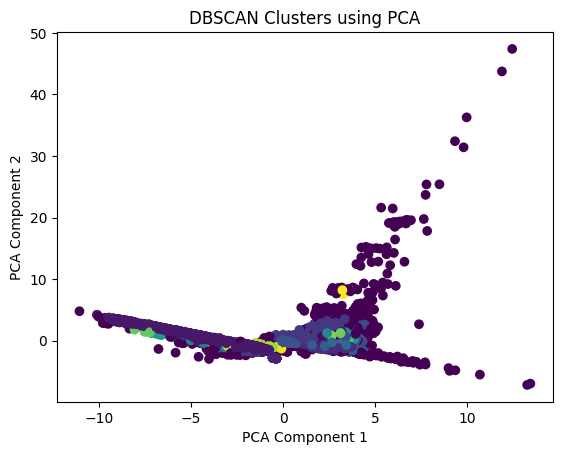

In [ ]:
#DBSCAN Clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)

plt.title("DBSCAN Clusters using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

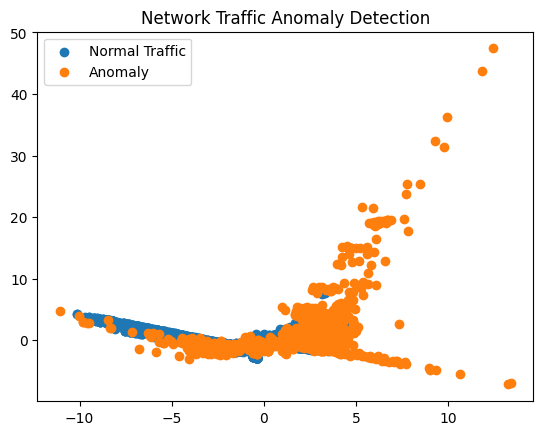

In [ ]:
#Network Traffic Anamoly Detection
normal = X_pca[clusters != -1]
anomaly = X_pca[clusters == -1]

plt.scatter(normal[:,0], normal[:,1], label="Normal Traffic")
plt.scatter(anomaly[:,0], anomaly[:,1], label="Anomaly")

plt.legend()

plt.title("Network Traffic Anomaly Detection")

plt.show()

In [25]:
#Pattern Discovery 
interaction_matrix = pd.pivot_table(
    df_sample,
    values='dur',
    index='proto',
    columns='service',
    aggfunc='mean'
).fillna(0)

interaction_matrix.head()

service,0,1,2,3,4,5,6,7,9,11,12
proto,,,,,,,,,,,
0,0.000010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
#Collaborative Filtering (Computing similarity)
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(interaction_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=interaction_matrix.index,
    columns=interaction_matrix.index
)

similarity_df.head()

proto,0,1,2,3,4,5,6,7,8,9,...,121,122,123,124,125,126,127,128,129,130
proto,,,,,,,,,,,,,,,,,,,,,
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
#Recommendation Function
def recommend_similar_protocol(protocol, n=3):

    similar = similarity_df[protocol].sort_values(ascending=False)[1:n+1]

    return similar
recommend_similar_protocol(interaction_matrix.index[0])

proto
1    1.0
2    1.0
3    1.0
Name: 0, dtype: float64

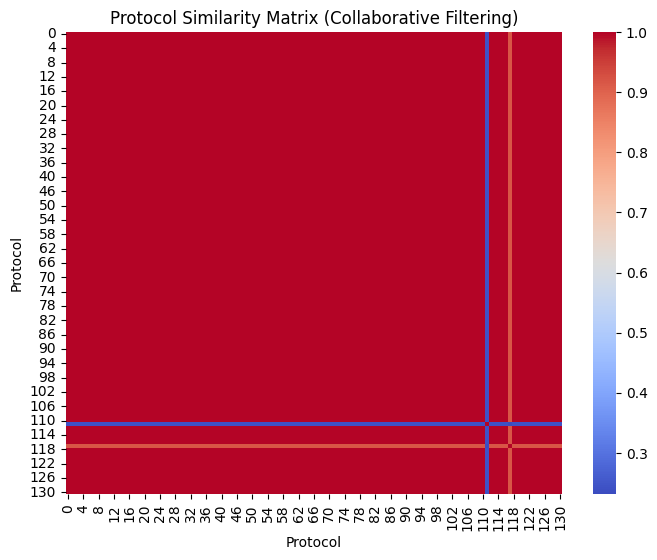

In [29]:
#Similarity Matrix Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(similarity_df, cmap="coolwarm")

plt.title("Protocol Similarity Matrix (Collaborative Filtering)")
plt.xlabel("Protocol")
plt.ylabel("Protocol")

plt.show()

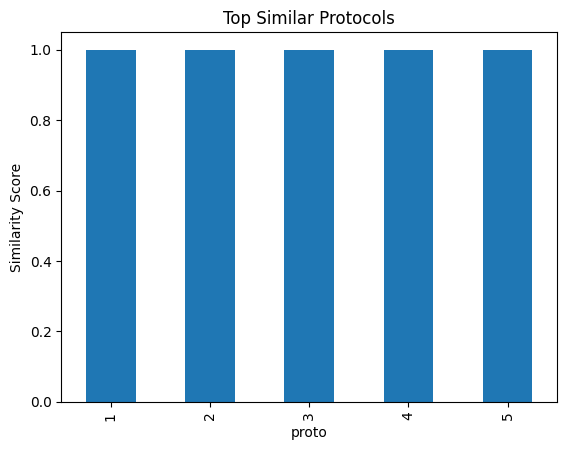

In [ ]:
#Top Similar Products
similar_protocols = similarity_df.iloc[0].sort_values(ascending=False)[1:6]

similar_protocols.plot(kind='bar')

plt.title("Top Similar Protocols")
plt.ylabel("Similarity Score")

plt.show()